#Exercise 4: NumPy Array Operations

In [1]:
import numpy as np

# Task 1
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

print("Task 1 Result:")
print(matrix)

Task 1 Result:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [2]:
# Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized_data = (
    random_data - random_data.mean(axis=0)
) / random_data.std(axis=0)

print("Column Means:")
print(normalized_data.mean(axis=0))

print("\nColumn Standard Deviations:")
print(normalized_data.std(axis=0))

Column Means:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Column Standard Deviations:
[1. 1. 1.]


In [3]:
# Task 3
X = np.random.randn(50, 3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

# Normal Equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated Coefficients:")
print(theta_hat)

print("\nTrue Coefficients:")
print(true_theta)

Estimated Coefficients:
[ 2.51723721 -1.19783796  3.72399266]

True Coefficients:
[ 2.5 -1.2  3.7]


# Exercise 5: Pandas Data Analysis


In [5]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [6]:
# Display basic information
print("Dataset Information:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())

# Count missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing exam_score with mean score of student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median of student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

First 5 Rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                     

In [7]:
# Average exam score by major
avg_score_by_major = df.groupby('major')['exam_score'].mean()

print("Average Exam Score by Major:")
print(avg_score_by_major)

# Major with highest average score
best_major = avg_score_by_major.idxmax()

print("\nMajor with Highest Average Score:")
print(best_major)

# Correlation
correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation between Hours Studied and Exam Score:")
print(correlation)

# Performance categories
df['performance'] = pd.cut(
    df['exam_score'],
    bins=[0, 70, 80, 90, 100],
    labels=[
        'Needs Improvement',
        'Average',
        'Good',
        'Excellent'
    ],
    include_lowest=True
)

print("\nPerformance Distribution:")
print(df['performance'].value_counts())

Average Exam Score by Major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with Highest Average Score:
CS

Correlation between Hours Studied and Exam Score:
-0.05598138347292439

Performance Distribution:
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [8]:
# Major-Year summary
summary = df.groupby(['major', 'year']).agg({
    'student_id': 'count',
    'exam_score': 'mean',
    'hours_studied': 'mean'
}).rename(columns={
    'student_id': 'Number_of_Students',
    'exam_score': 'Average_Exam_Score',
    'hours_studied': 'Average_Hours_Studied'
})

print("Major-Year Summary:")
print(summary)

# Top 5 students
top_students = df.nlargest(5, 'exam_score')

print("\nTop 5 Students:")
print(top_students[
    ['student_id', 'major', 'year', 'exam_score']
])

# Pivot table
pivot_table = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table:")
print(pivot_table)

Major-Year Summary:
              Number_of_Students  Average_Exam_Score  Average_Hours_Studied
major   year                                                               
Biology 1                     13           76.570059              12.677806
        2                     12           74.899613              13.426372
        3                     14           80.178476              14.486815
        4                     15           70.697689              14.253944
CS      1                     12           77.098194              13.039480
        2                      7           76.155936              13.995784
        3                      9           72.347626              15.039892
        4                     18           78.119997              16.275541
Math    1                     11           74.053167              19.001215
        2                      9           81.226714              12.345468
        3                     10           72.017537              15

# Exercise 6: Data Visualization

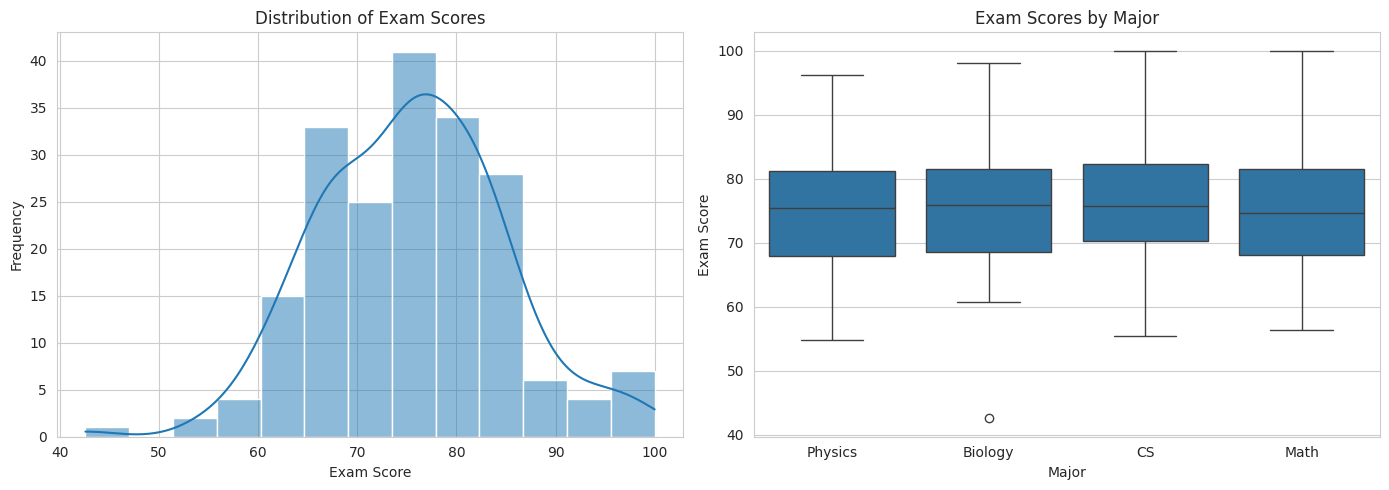

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

# Box plot by major
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

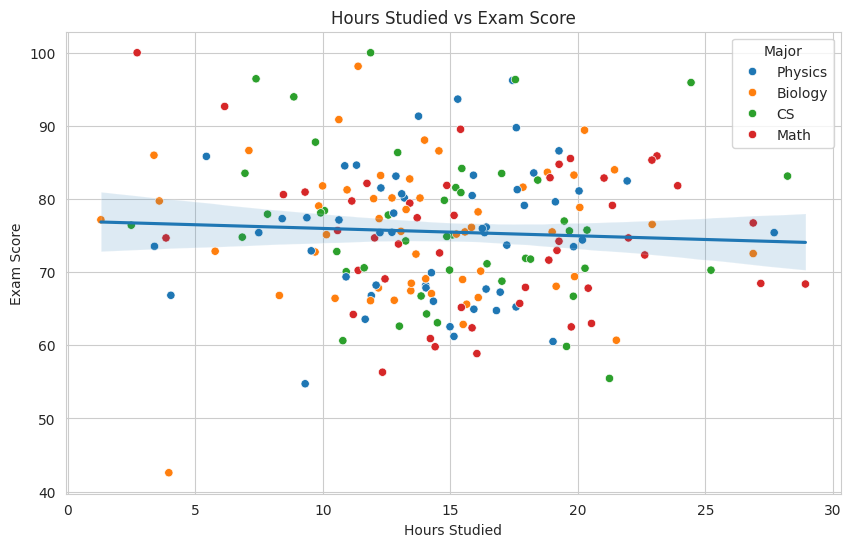

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

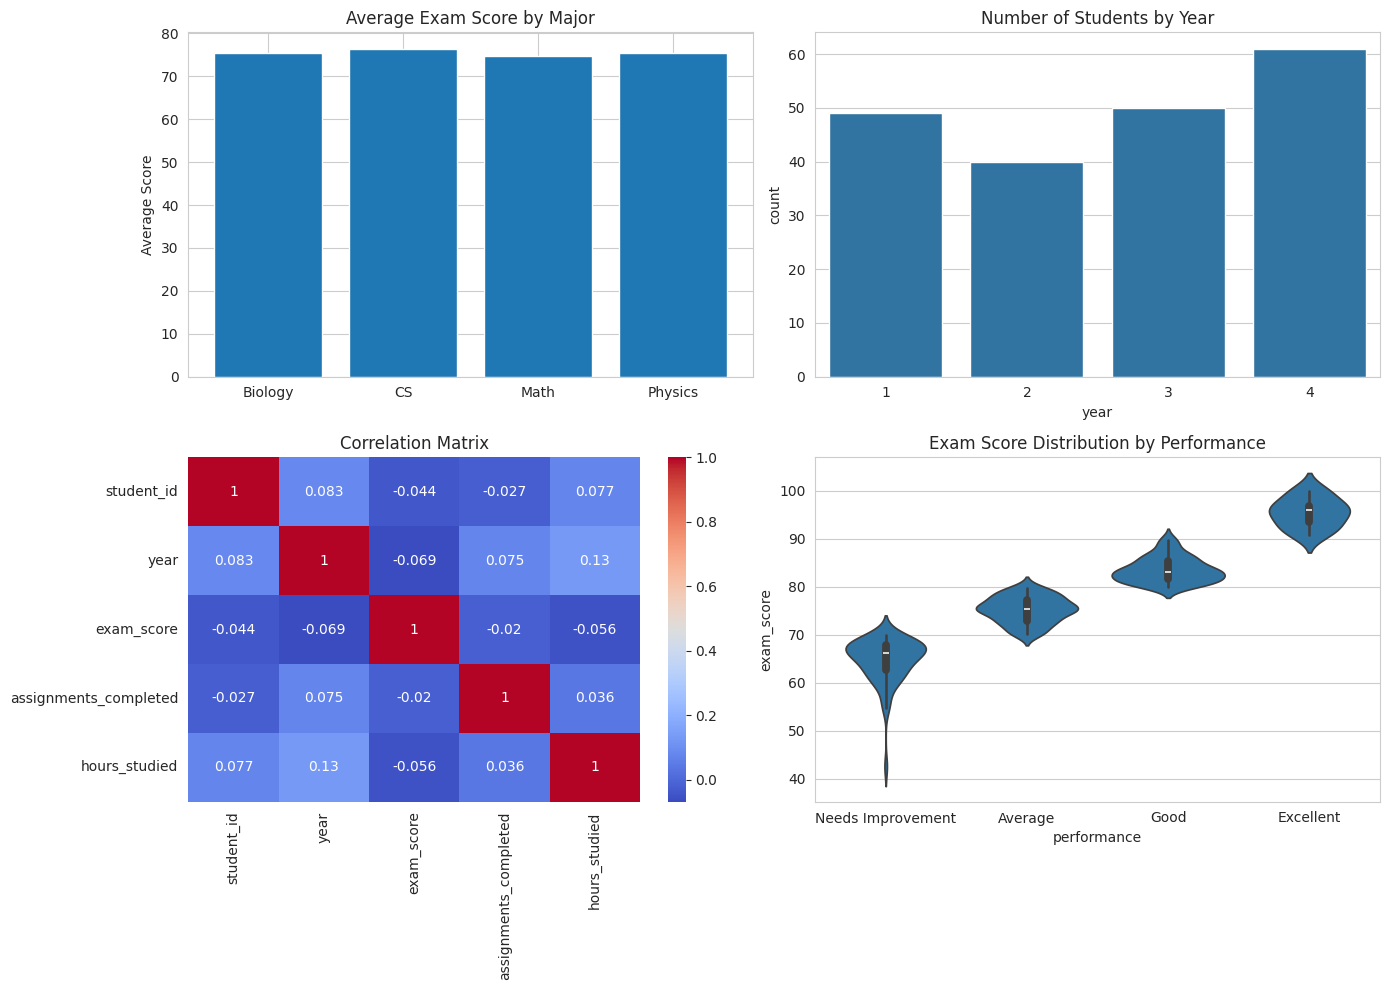

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average score by major
avg_scores = df.groupby('major')['exam_score'].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_ylabel("Average Score")

# 2. Student count by year
sns.countplot(data=df, x='year', ax=axes[0, 1])
axes[0, 1].set_title("Number of Students by Year")

# 3. Correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[1, 0]
)

axes[1, 0].set_title("Correlation Matrix")

# 4. Violin plot
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title("Exam Score Distribution by Performance")

plt.tight_layout()
plt.show()

# Exercise 7: Integration Challenge


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

customers.head()

,age,income,purchase_frequency,avg_purchase_value
0,56,92443.123940,7,94.527456
1,69,70649.305211,2,100.932279
2,46,19612.600681,3,79.699876
3,32,40315.318543,2,130.137787
4,60,75338.222984,8,102.904845


In [13]:
# Calculate CLV

max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency
)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

# Create age groups

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)

customers.head()

,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
0,56,92443.123940,7,94.527456,0.416667,937.397271,51-70
1,69,70649.305211,2,100.932279,0.833333,370.085023,51-70
2,46,19612.600681,3,79.699876,0.750000,418.424348,36-50
3,32,40315.318543,2,130.137787,0.833333,477.171887,26-35
4,60,75338.222984,8,102.904845,0.333333,1097.651683,51-70


In [14]:
age_group_summary = customers.groupby('age_group').agg({
    'age': 'count',
    'income': 'mean',
    'CLV': ['mean', 'sum']
})

age_group_summary.columns = [
    'Number_of_Customers',
    'Average_Income',
    'Average_CLV',
    'Total_CLV'
]

print(age_group_summary)


           Number_of_Customers  Average_Income  Average_CLV      Total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683


/tmp/ipykernel_12194/3650249773.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_summary = customers.groupby('age_group').agg({


In [15]:
top_10_percent = customers.nlargest(
    int(len(customers) * 0.10),
    'CLV'
)

print("Top 10% Customers")
print(top_10_percent.head())

print(f"\nNumber of Top Customers: {len(top_10_percent)}")

Top 10% Customers
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   

             CLV age_group  
426  1645.711441     36-50  
213  1635.458860     36-50  
410  1593.874900     36-50  
194  1589.765308     36-50  
244  1584.534373     26-35  

Number of Top Customers: 50


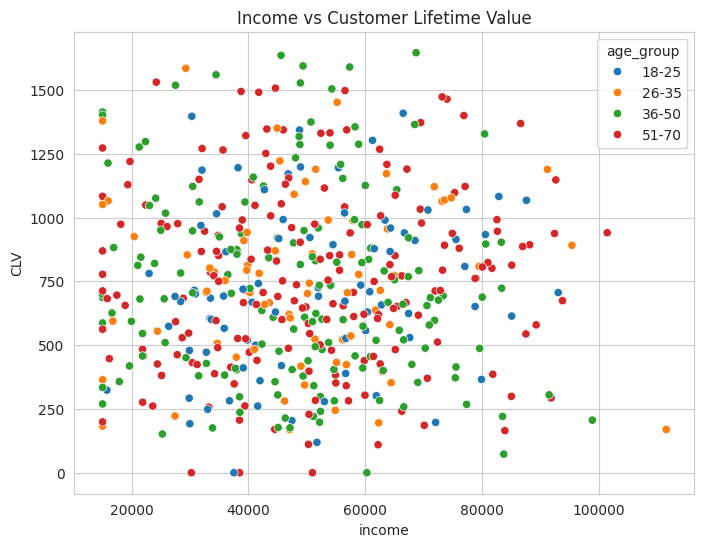

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.show()

/tmp/ipykernel_12194/799560657.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


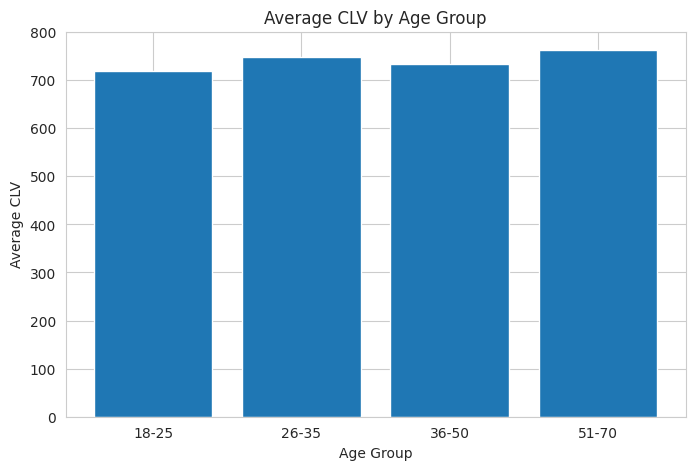

In [17]:
avg_clv = customers.groupby('age_group')['CLV'].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_clv.index.astype(str),
        avg_clv.values)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')

plt.show()

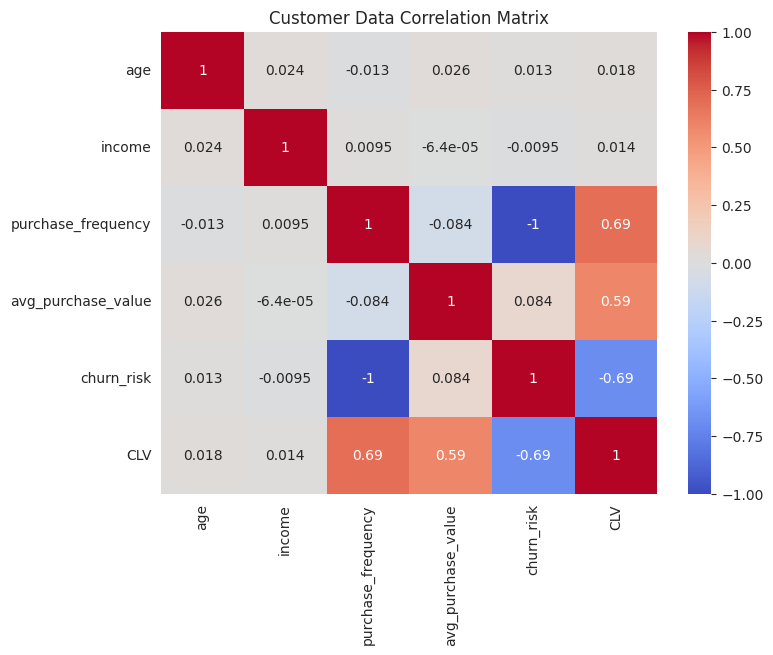

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    customers.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Customer Data Correlation Matrix')

plt.show()

## Analysis and Recommendations

From the analysis, it was observed that customer lifetime value (CLV) differs across the various age groups. Customers who made purchases more frequently generally had higher CLV values, showing that purchase frequency has a strong impact on customer value. While income may influence spending habits, it did not appear to have as strong an effect on CLV as purchase frequency.

The results also showed that the top 10% of customers contribute a large share of the overall customer value. This suggests that retaining loyal and active customers is important for the company's success.

Based on these findings, the company should focus on keeping its high-value customers engaged through loyalty programs, special discounts, and personalized offers. It would also be beneficial to target age groups with higher average CLV through marketing campaigns in order to encourage repeat purchases and increase overall revenue.